# Step 2 — Train and Tune SVM Classifier

Loads the feature matrix from `01_extract_dataset.ipynb` and trains an **RBF SVM classifier**
(LEFT / STRAIGHT / RIGHT) as required by the lab.

The SVM predicts a discrete class. To satisfy the `detect_line()` interface which requires a
**continuous float in `[-1.0, 1.0]`**, each class is mapped to a fixed steering value:

| Class | Steering value |
|-------|---------------|
| LEFT | −1.0 |
| STRAIGHT | 0.0 |
| RIGHT | +1.0 |

**Input files (from `data/`):**
- `X_features.npy`
- `y_labels.npy`

**Output (saved to `models/`):**
- `svm_line_follower.pkl` — tuned Pipeline (StandardScaler + PCA + SVC)

## 1. Imports and paths

In [ ]:
from pathlib import Path
import pickle

import matplotlib.pyplot as plt
import numpy as np

from sklearn.decomposition import PCA
from sklearn.metrics import (
    ConfusionMatrixDisplay, accuracy_score, classification_report,
    confusion_matrix, f1_score,
)
from sklearn.model_selection import GridSearchCV, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

REPO_ROOT   = Path(r"C:/Users/danie/Desktop/Autonomous_Team4/GitBranch_Simulation")
DATA_DIR    = REPO_ROOT / "Autonomous_Systems_A_Lab_Group_4" / "data"
MODELS_DIR  = REPO_ROOT / "Autonomous_Systems_A_Lab_Group_4" / "models"
MODELS_DIR.mkdir(exist_ok=True)

CLASS_NAMES = np.array(["LEFT", "STRAIGHT", "RIGHT"])

## 2. Load dataset

In [ ]:
X = np.load(str(DATA_DIR / "X_features.npy"))
y = np.load(str(DATA_DIR / "y_labels.npy"))

print(f"X: {X.shape},  y: {y.shape}")
print("Class distribution:")
for i, name in enumerate(CLASS_NAMES):
    n = (y == i).sum()
    print(f"  {name:10s}: {n:5d}  ({100*n/len(y):.1f}%)")

steer_map = np.array([-1.0, 0.0, 1.0], dtype=np.float32)  # LEFT, STRAIGHT, RIGHT

print("\nSteering map:")
for i, name in enumerate(CLASS_NAMES):
    print(f"  {name:10s}: {steer_map[i]:+.1f}")

## 3. Train / test split

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)
print("Train:", X_train.shape, "  Test:", X_test.shape)

Train: (12006, 4098)   Test: (4003, 4098)


## 4. Baseline SVM (C=1, gamma=scale)

Pipeline: `StandardScaler → PCA(100) → SVC(rbf)`

- **StandardScaler**: normalises each feature to zero mean, unit variance — required before PCA
- **PCA(100)**: reduces 4,098 dims → 100 principal components (~40× faster for SVM)
- **class_weight="balanced"**: compensates for class imbalance (STRAIGHT is majority class)

Baseline accuracy : 0.8426180364726455
Baseline macro F1 : 0.7992

              precision    recall  f1-score   support

        LEFT       0.89      0.86      0.87      1654
    STRAIGHT       0.54      0.74      0.62       573
       RIGHT       0.94      0.86      0.90      1776

    accuracy                           0.84      4003
   macro avg       0.79      0.82      0.80      4003
weighted avg       0.86      0.84      0.85      4003



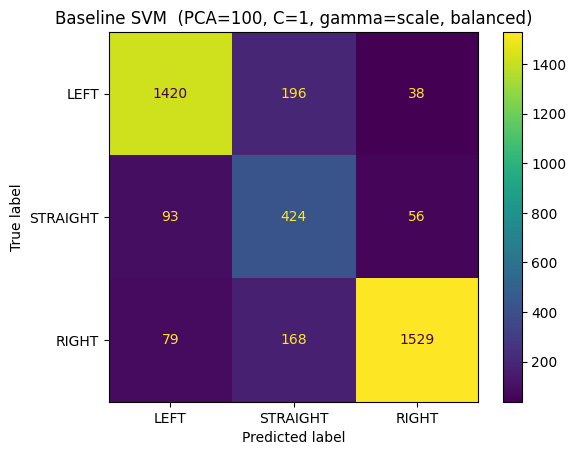

In [4]:
baseline = Pipeline([
    ("scaler", StandardScaler()),
    ("pca",    PCA(n_components=100, random_state=RANDOM_STATE)),
    ("svm",    SVC(kernel="rbf", C=1.0, gamma="scale",
                  class_weight="balanced", random_state=RANDOM_STATE)),
])
baseline.fit(X_train, y_train)
y_pred_base = baseline.predict(X_test)

print("Baseline accuracy :", accuracy_score(y_test, y_pred_base))
print("Baseline macro F1 :", round(f1_score(y_test, y_pred_base, average="macro"), 4))
print()
print(classification_report(y_test, y_pred_base, target_names=CLASS_NAMES))

ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, y_pred_base),
    display_labels=CLASS_NAMES,
).plot()
plt.title("Baseline SVM  (PCA=100, C=1, gamma=scale, balanced)")
plt.show()

## 5. Cross-validation on baseline

In [5]:
cv_scores = cross_val_score(baseline, X_train, y_train, cv=3, scoring="f1_macro", n_jobs=1)
print("3-fold macro F1:", np.round(cv_scores, 4))
print(f"Mean: {cv_scores.mean():.4f}  Std: {cv_scores.std():.4f}")

3-fold macro F1: [0.7729 0.7649 0.7747]
Mean: 0.7709  Std: 0.0042


## 6. GridSearchCV — tune C

In [6]:
param_grid = {
    "svm__C":     [0.1, 1, 10, 100, 500],
    "svm__gamma": ["scale"],
}

grid = GridSearchCV(
    Pipeline([
        ("scaler", StandardScaler()),
        ("pca",    PCA(n_components=100, random_state=RANDOM_STATE)),
        ("svm",    SVC(kernel="rbf", class_weight="balanced", random_state=RANDOM_STATE)),
    ]),
    param_grid=param_grid,
    scoring="f1_macro",
    cv=3,
    n_jobs=1,
    verbose=1,
)
grid.fit(X_train, y_train)

print("Best parameters :", grid.best_params_)
print("Best CV macro F1:", round(grid.best_score_, 4))

Fitting 3 folds for each of 5 candidates, totalling 15 fits


Best parameters : {'svm__C': 100, 'svm__gamma': 'scale'}
Best CV macro F1: 0.7987


## 7. Evaluate tuned model on held-out test set

Tuned accuracy : 0.8735948038970772
Tuned macro F1 : 0.8224

              precision    recall  f1-score   support

        LEFT       0.87      0.92      0.89      1654
    STRAIGHT       0.71      0.61      0.65       573
       RIGHT       0.92      0.92      0.92      1776

    accuracy                           0.87      4003
   macro avg       0.83      0.81      0.82      4003
weighted avg       0.87      0.87      0.87      4003



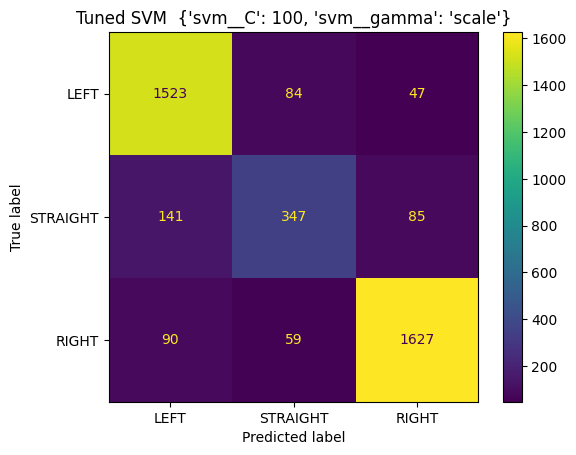

In [7]:
best_model  = grid.best_estimator_
y_pred_best = best_model.predict(X_test)

print("Tuned accuracy :", accuracy_score(y_test, y_pred_best))
print("Tuned macro F1 :", round(f1_score(y_test, y_pred_best, average="macro"), 4))
print()
print(classification_report(y_test, y_pred_best, target_names=CLASS_NAMES))

ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, y_pred_best),
    display_labels=CLASS_NAMES,
).plot()
plt.title(f"Tuned SVM  {grid.best_params_}")
plt.show()

## 8. Save model and steering map

In [ ]:
MODEL_PATH = MODELS_DIR / "svm_line_follower.pkl"

with open(str(MODEL_PATH), "wb") as f:
    pickle.dump(best_model, f)

print("Model saved:", MODEL_PATH)

# Verify load + predict
with open(str(MODEL_PATH), "rb") as f:
    loaded = pickle.load(f)
steer_map  = np.array([-1.0, 0.0, 1.0], dtype=np.float32)  # LEFT, STRAIGHT, RIGHT
pred_cls   = loaded.predict(X_test[:5])
pred_steer = np.array([float(np.clip(steer_map[c], -1.0, 1.0)) for c in pred_cls])
print("\nExample predictions (class → float):")
for cls, steer in zip(CLASS_NAMES[pred_cls], pred_steer):
    print(f"  {cls:10s} → {steer:+.2f}")
print("\nDone. Run 03_evaluate.ipynb for visual inspection.")